<a href="https://colab.research.google.com/github/baanujan-18/PLC---Automation/blob/main/Knight%20Rider%20Pattern/colab/KnightRider_Pattern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

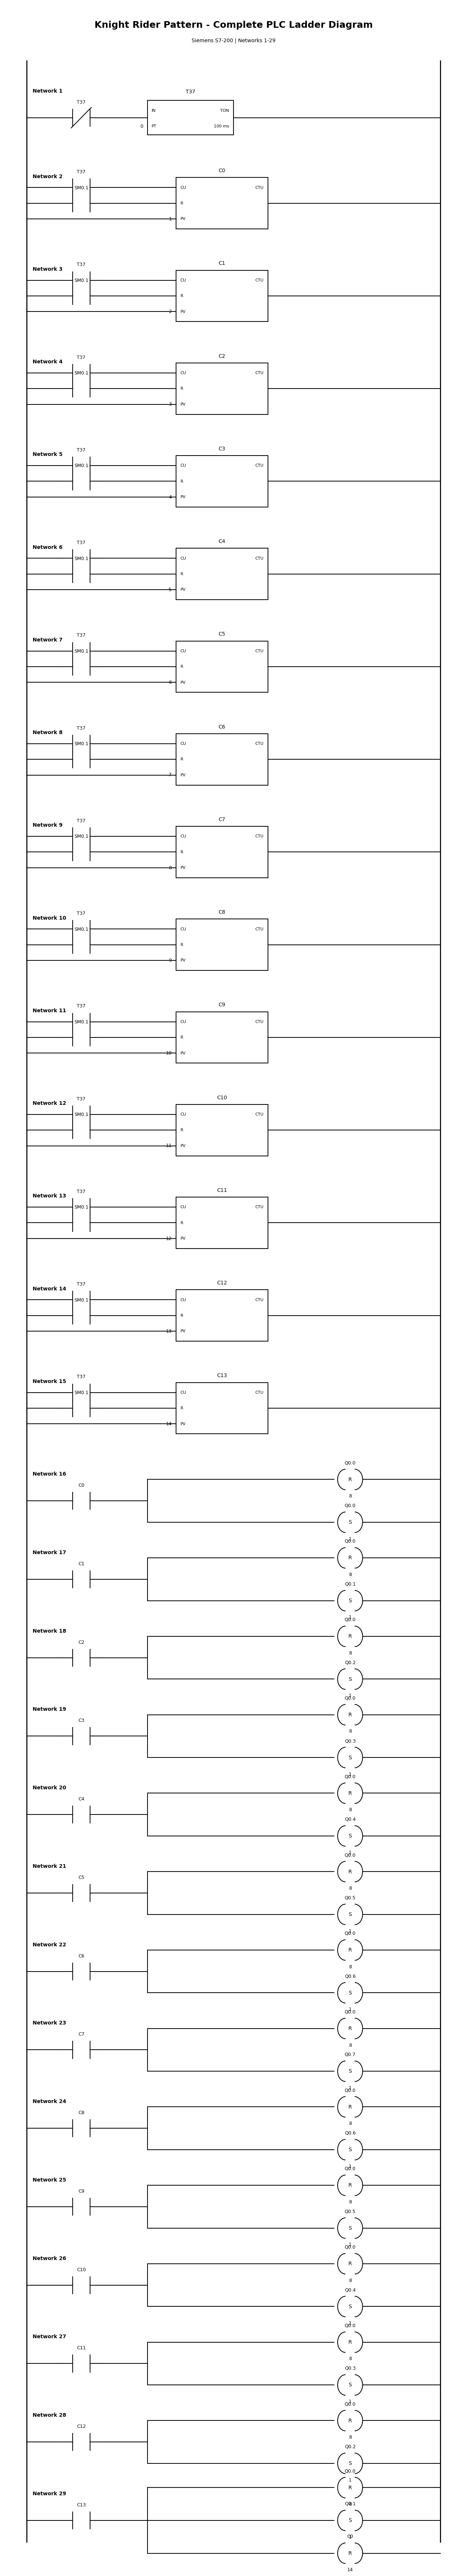

Files created successfully:
knight_rider_full_ladder.png
knight_rider_full_ladder.pdf


In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc
from pathlib import Path

# ============================================================
# KNIGHT RIDER PLC LADDER DIAGRAM
# ONE CONTINUOUS BLACK-AND-WHITE DRAWING
#
# Sequence:
# Q0.0 -> Q0.1 -> Q0.2 -> Q0.3 -> Q0.4 -> Q0.5 -> Q0.6
# -> Q0.7 -> Q0.6 -> Q0.5 -> Q0.4 -> Q0.3 -> Q0.2 -> Q0.1
# -> repeat
# ============================================================

BLACK = "black"

LEFT_RAIL = 0.8
RIGHT_RAIL = 15.2

FIGURE_HEIGHT = 90

fig, ax = plt.subplots(figsize=(16, FIGURE_HEIGHT))

ax.set_xlim(0, 16)
ax.set_ylim(0, FIGURE_HEIGHT)
ax.axis("off")

# Main vertical rails
ax.plot(
    [LEFT_RAIL, LEFT_RAIL],
    [1, FIGURE_HEIGHT - 2],
    linewidth=2,
    color=BLACK
)

ax.plot(
    [RIGHT_RAIL, RIGHT_RAIL],
    [1, FIGURE_HEIGHT - 2],
    linewidth=2,
    color=BLACK
)


# ============================================================
# BASIC DRAWING FUNCTIONS
# ============================================================

def horizontal_wire(x1, x2, y, linewidth=1.5):
    ax.plot(
        [x1, x2],
        [y, y],
        linewidth=linewidth,
        color=BLACK
    )


def vertical_wire(x, y1, y2, linewidth=1.5):
    ax.plot(
        [x, x],
        [y1, y2],
        linewidth=linewidth,
        color=BLACK
    )


def network_label(number, y):
    ax.text(
        1.0,
        y + 0.85,
        f"Network {number}",
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=BLACK
    )


def contact(x, y, label, normally_closed=False):
    """
    Draw a normally open or normally closed contact.
    """

    horizontal_wire(x, x + 0.40, y)

    ax.plot(
        [x + 0.40, x + 0.40],
        [y - 0.30, y + 0.30],
        linewidth=1.5,
        color=BLACK
    )

    ax.plot(
        [x + 1.00, x + 1.00],
        [y - 0.30, y + 0.30],
        linewidth=1.5,
        color=BLACK
    )

    if normally_closed:
        ax.plot(
            [x + 0.35, x + 1.05],
            [y - 0.36, y + 0.36],
            linewidth=1.5,
            color=BLACK
        )

    horizontal_wire(x + 1.00, x + 1.40, y)

    ax.text(
        x + 0.70,
        y + 0.46,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        color=BLACK
    )

    return x + 1.40


def instruction_coil(x, y, address, mode, quantity):
    """
    Draw Siemens SET or RESET instruction.

    mode:
    S = Set
    R = Reset
    """

    horizontal_wire(x, x + 0.30, y)

    ax.add_patch(
        Arc(
            (x + 0.70, y),
            width=0.55,
            height=0.72,
            theta1=90,
            theta2=270,
            linewidth=1.5,
            color=BLACK
        )
    )

    ax.add_patch(
        Arc(
            (x + 1.02, y),
            width=0.55,
            height=0.72,
            theta1=-90,
            theta2=90,
            linewidth=1.5,
            color=BLACK
        )
    )

    ax.text(
        x + 0.86,
        y,
        mode,
        ha="center",
        va="center",
        fontsize=10,
        color=BLACK
    )

    ax.text(
        x + 0.86,
        y + 0.50,
        address,
        ha="center",
        va="bottom",
        fontsize=9,
        color=BLACK
    )

    ax.text(
        x + 0.86,
        y - 0.50,
        str(quantity),
        ha="center",
        va="top",
        fontsize=9,
        color=BLACK
    )

    horizontal_wire(
        x + 1.32,
        RIGHT_RAIL,
        y
    )


def ton_block(x, y, timer_name, preset, time_base="100 ms"):
    """
    Draw a TON timer block.
    """

    width = 3.0
    height = 1.20

    ax.add_patch(
        Rectangle(
            (x, y - height / 2),
            width,
            height,
            fill=False,
            linewidth=1.5,
            edgecolor=BLACK
        )
    )

    ax.text(
        x + 0.15,
        y + 0.25,
        "IN",
        fontsize=8,
        ha="left",
        va="center",
        color=BLACK
    )

    ax.text(
        x + width - 0.15,
        y + 0.25,
        "TON",
        fontsize=8,
        ha="right",
        va="center",
        color=BLACK
    )

    ax.text(
        x + 0.15,
        y - 0.30,
        "PT",
        fontsize=8,
        ha="left",
        va="center",
        color=BLACK
    )

    ax.text(
        x + width - 0.15,
        y - 0.30,
        time_base,
        fontsize=8,
        ha="right",
        va="center",
        color=BLACK
    )

    ax.text(
        x + width / 2,
        y + 0.82,
        timer_name,
        fontsize=10,
        ha="center",
        va="bottom",
        color=BLACK
    )

    ax.text(
        x - 0.15,
        y - 0.30,
        str(preset),
        fontsize=9,
        ha="right",
        va="center",
        color=BLACK
    )

    return x + width


def ctu_block(x, y, counter_name, preset):
    """
    Draw a CTU counter block.
    """

    width = 3.2
    height = 1.80

    ax.add_patch(
        Rectangle(
            (x, y - height / 2),
            width,
            height,
            fill=False,
            linewidth=1.5,
            edgecolor=BLACK
        )
    )

    ax.text(
        x + 0.15,
        y + 0.55,
        "CU",
        fontsize=8,
        ha="left",
        va="center",
        color=BLACK
    )

    ax.text(
        x + 0.15,
        y,
        "R",
        fontsize=8,
        ha="left",
        va="center",
        color=BLACK
    )

    ax.text(
        x + 0.15,
        y - 0.55,
        "PV",
        fontsize=8,
        ha="left",
        va="center",
        color=BLACK
    )

    ax.text(
        x + width - 0.15,
        y + 0.55,
        "CTU",
        fontsize=8,
        ha="right",
        va="center",
        color=BLACK
    )

    ax.text(
        x + width / 2,
        y + 1.05,
        counter_name,
        fontsize=10,
        ha="center",
        va="bottom",
        color=BLACK
    )

    ax.text(
        x - 0.15,
        y - 0.55,
        str(preset),
        fontsize=9,
        ha="right",
        va="center",
        color=BLACK
    )

    return x + width


# ============================================================
# NETWORK 1
# NC T37 CONTACT -> TON T37
# ============================================================

current_y = FIGURE_HEIGHT - 4

network_label(1, current_y)

horizontal_wire(
    LEFT_RAIL,
    2.0,
    current_y
)

end_contact = contact(
    2.0,
    current_y,
    "T37",
    normally_closed=True
)

horizontal_wire(
    end_contact,
    5.0,
    current_y
)

end_timer = ton_block(
    5.0,
    current_y,
    "T37",
    preset=0,
    time_base="100 ms"
)

horizontal_wire(
    end_timer,
    RIGHT_RAIL,
    current_y
)

current_y -= 3.0


# ============================================================
# NETWORKS 2 TO 15
# COUNTERS C0 TO C13
# ============================================================

for network_number, counter_number, preset_value in zip(
    range(2, 16),
    range(0, 14),
    range(1, 15)
):

    network_label(
        network_number,
        current_y
    )

    cu_y = current_y + 0.55
    reset_y = current_y
    pv_y = current_y - 0.55

    # T37 contact to CU input
    horizontal_wire(
        LEFT_RAIL,
        2.0,
        cu_y
    )

    end_contact = contact(
        2.0,
        cu_y,
        "T37"
    )

    horizontal_wire(
        end_contact,
        6.0,
        cu_y
    )

    # SM0.1 contact to counter reset
    horizontal_wire(
        LEFT_RAIL,
        2.0,
        reset_y
    )

    end_contact = contact(
        2.0,
        reset_y,
        "SM0.1"
    )

    horizontal_wire(
        end_contact,
        6.0,
        reset_y
    )

    # Preset line
    horizontal_wire(
        LEFT_RAIL,
        6.0,
        pv_y
    )

    end_counter = ctu_block(
        6.0,
        current_y,
        f"C{counter_number}",
        preset_value
    )

    horizontal_wire(
        end_counter,
        RIGHT_RAIL,
        current_y
    )

    current_y -= 3.25


# ============================================================
# OUTPUT SEQUENCE DATA
# NETWORKS 16 TO 29
# ============================================================

output_sequence = [
    (16, "C0",  "Q0.0", False),
    (17, "C1",  "Q0.1", False),
    (18, "C2",  "Q0.2", False),
    (19, "C3",  "Q0.3", False),
    (20, "C4",  "Q0.4", False),
    (21, "C5",  "Q0.5", False),
    (22, "C6",  "Q0.6", False),
    (23, "C7",  "Q0.7", False),
    (24, "C8",  "Q0.6", False),
    (25, "C9",  "Q0.5", False),
    (26, "C10", "Q0.4", False),
    (27, "C11", "Q0.3", False),
    (28, "C12", "Q0.2", False),
    (29, "C13", "Q0.1", True)
]


# ============================================================
# NETWORKS 16 TO 29
# RESET ALL OUTPUTS AND SET SELECTED OUTPUT
# ============================================================

for (
    network_number,
    counter_name,
    output_name,
    is_final_network
) in output_sequence:

    network_label(
        network_number,
        current_y
    )

    horizontal_wire(
        LEFT_RAIL,
        2.0,
        current_y
    )

    end_contact = contact(
        2.0,
        current_y,
        counter_name
    )

    branch_x = 5.0

    horizontal_wire(
        end_contact,
        branch_x,
        current_y
    )

    if is_final_network:

        top_y = current_y + 1.15
        middle_y = current_y
        bottom_y = current_y - 1.15

        vertical_wire(
            branch_x,
            bottom_y,
            top_y
        )

        # Reset Q0.0 through Q0.7
        horizontal_wire(
            branch_x,
            11.2,
            top_y
        )

        instruction_coil(
            11.2,
            top_y,
            "Q0.0",
            "R",
            8
        )

        # Set Q0.1
        horizontal_wire(
            branch_x,
            11.2,
            middle_y
        )

        instruction_coil(
            11.2,
            middle_y,
            output_name,
            "S",
            1
        )

        # Reset counters C0 through C13
        horizontal_wire(
            branch_x,
            11.2,
            bottom_y
        )

        instruction_coil(
            11.2,
            bottom_y,
            "C0",
            "R",
            14
        )

        current_y -= 3.5

    else:

        top_y = current_y + 0.75
        bottom_y = current_y - 0.75

        vertical_wire(
            branch_x,
            bottom_y,
            top_y
        )

        # Reset all eight outputs
        horizontal_wire(
            branch_x,
            11.2,
            top_y
        )

        instruction_coil(
            11.2,
            top_y,
            "Q0.0",
            "R",
            8
        )

        # Set selected output
        horizontal_wire(
            branch_x,
            11.2,
            bottom_y
        )

        instruction_coil(
            11.2,
            bottom_y,
            output_name,
            "S",
            1
        )

        current_y -= 2.75


# ============================================================
# TITLE
# ============================================================

ax.text(
    8.0,
    FIGURE_HEIGHT - 0.6,
    "Knight Rider Pattern - Complete PLC Ladder Diagram",
    ha="center",
    va="top",
    fontsize=18,
    fontweight="bold",
    color=BLACK
)

ax.text(
    8.0,
    FIGURE_HEIGHT - 1.2,
    "Siemens S7-200 | Networks 1-29",
    ha="center",
    va="top",
    fontsize=10,
    color=BLACK
)


# ============================================================
# SAVE ONE FULL PNG AND ONE FULL PDF
# ============================================================

plt.savefig(
    "knight_rider_full_ladder.png",
    dpi=220,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "knight_rider_full_ladder.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Files created successfully:")
print("knight_rider_full_ladder.png")
print("knight_rider_full_ladder.pdf")

In [4]:
from google.colab import files

files.download("knight_rider_full_ladder.png")
files.download("knight_rider_full_ladder.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

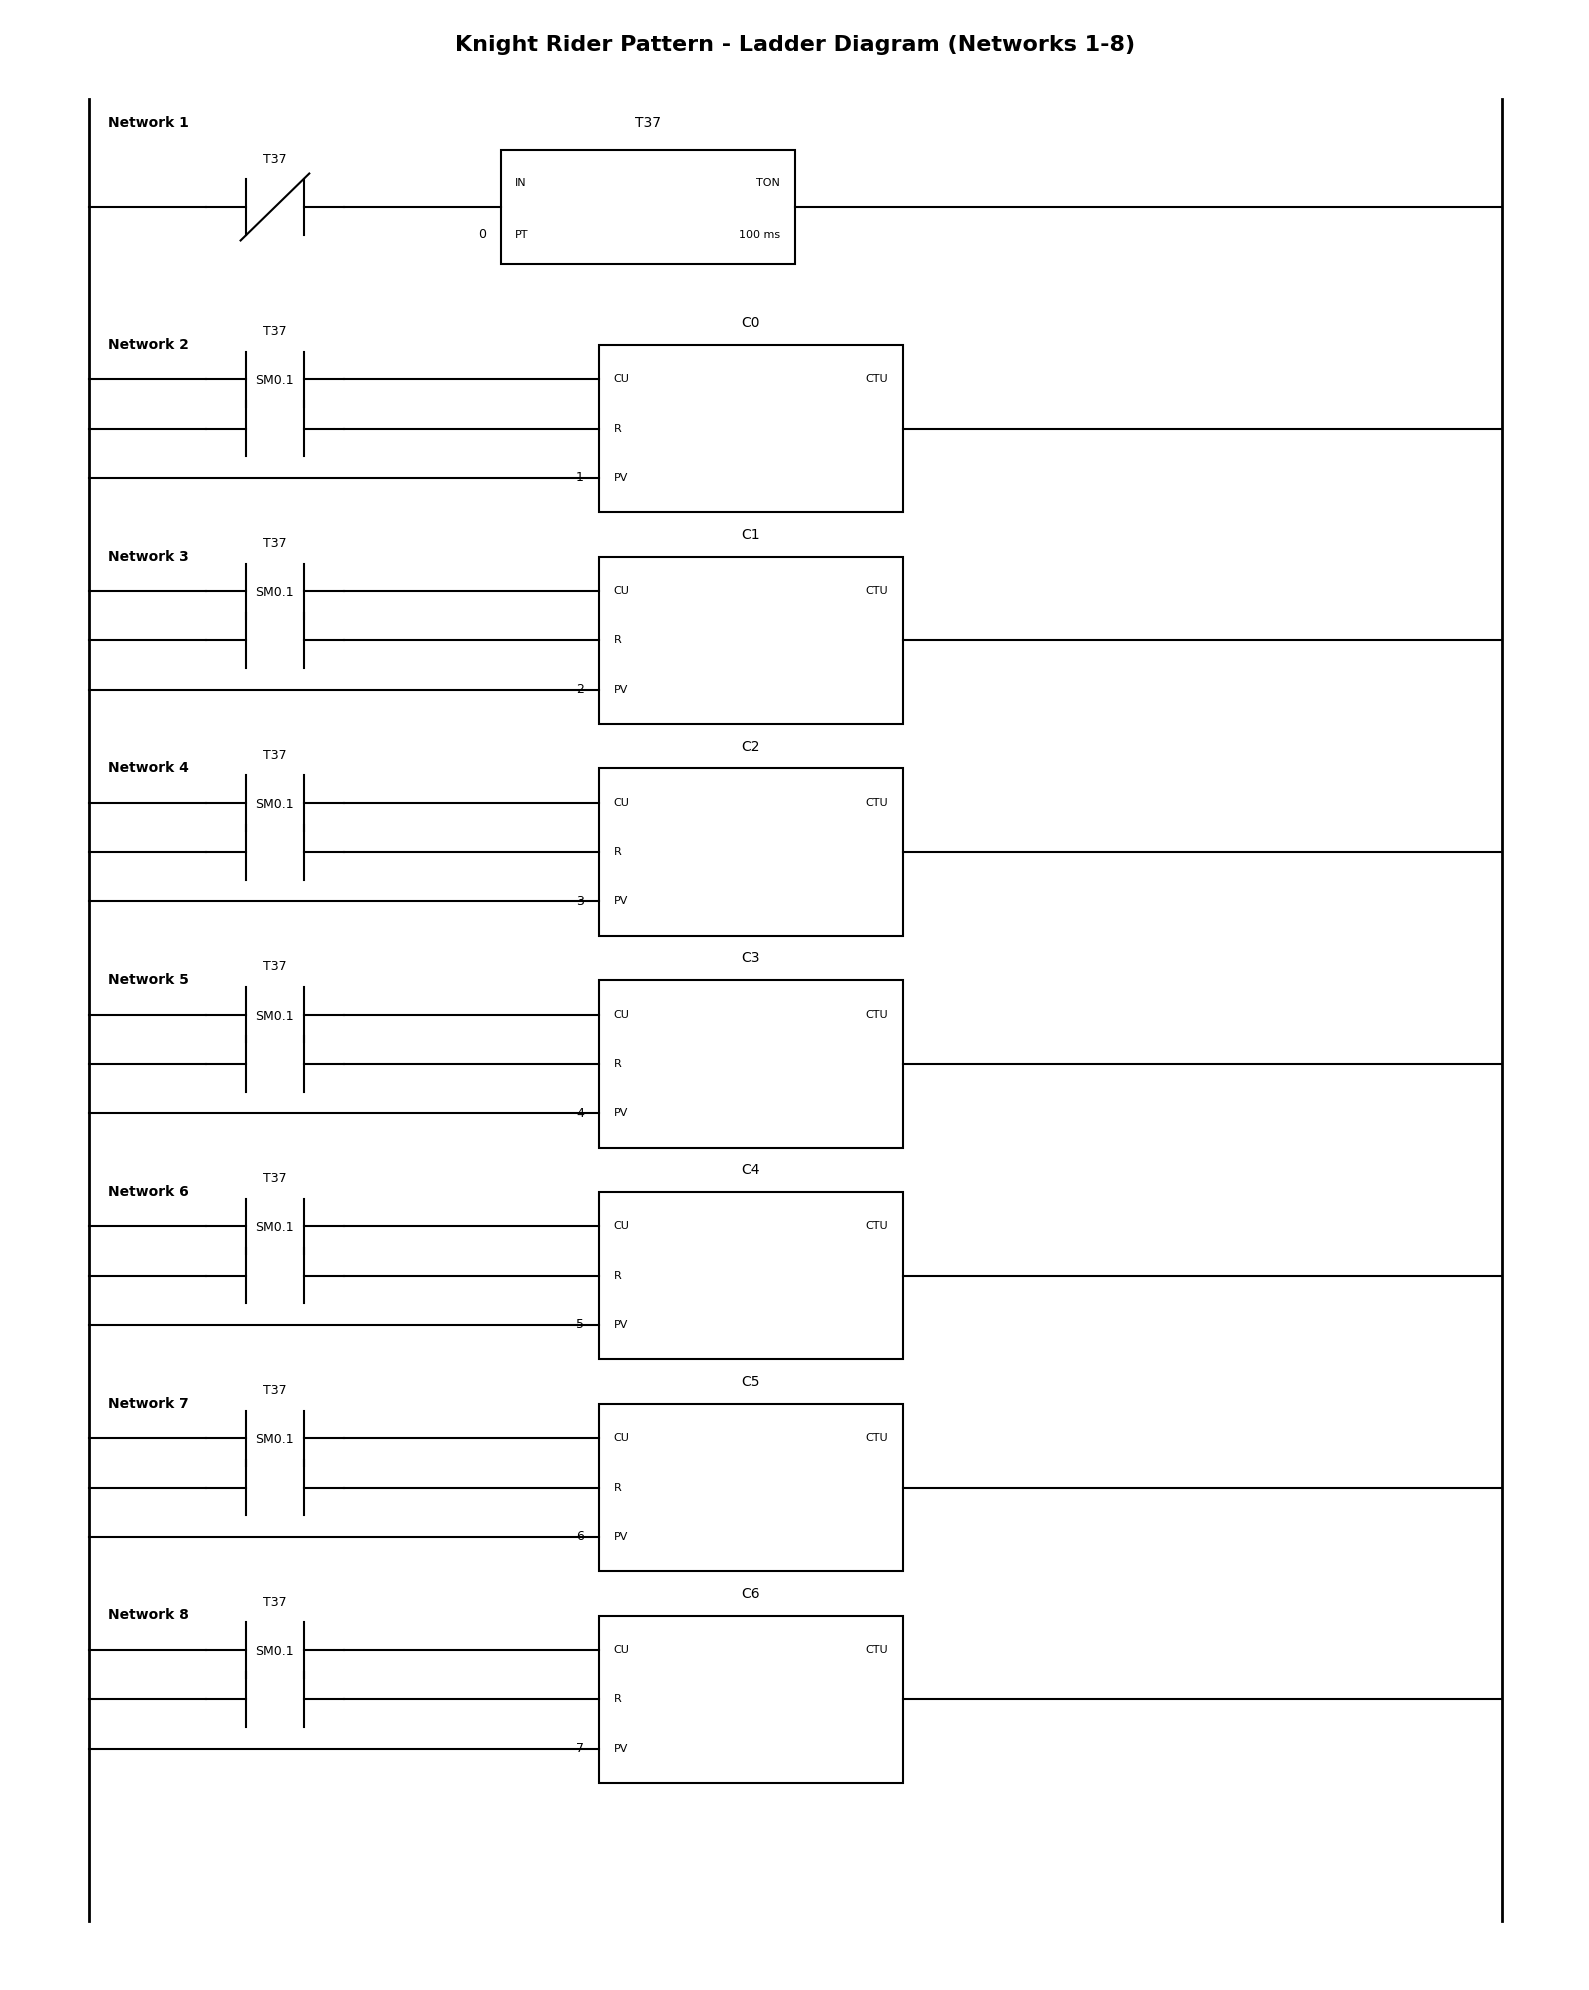

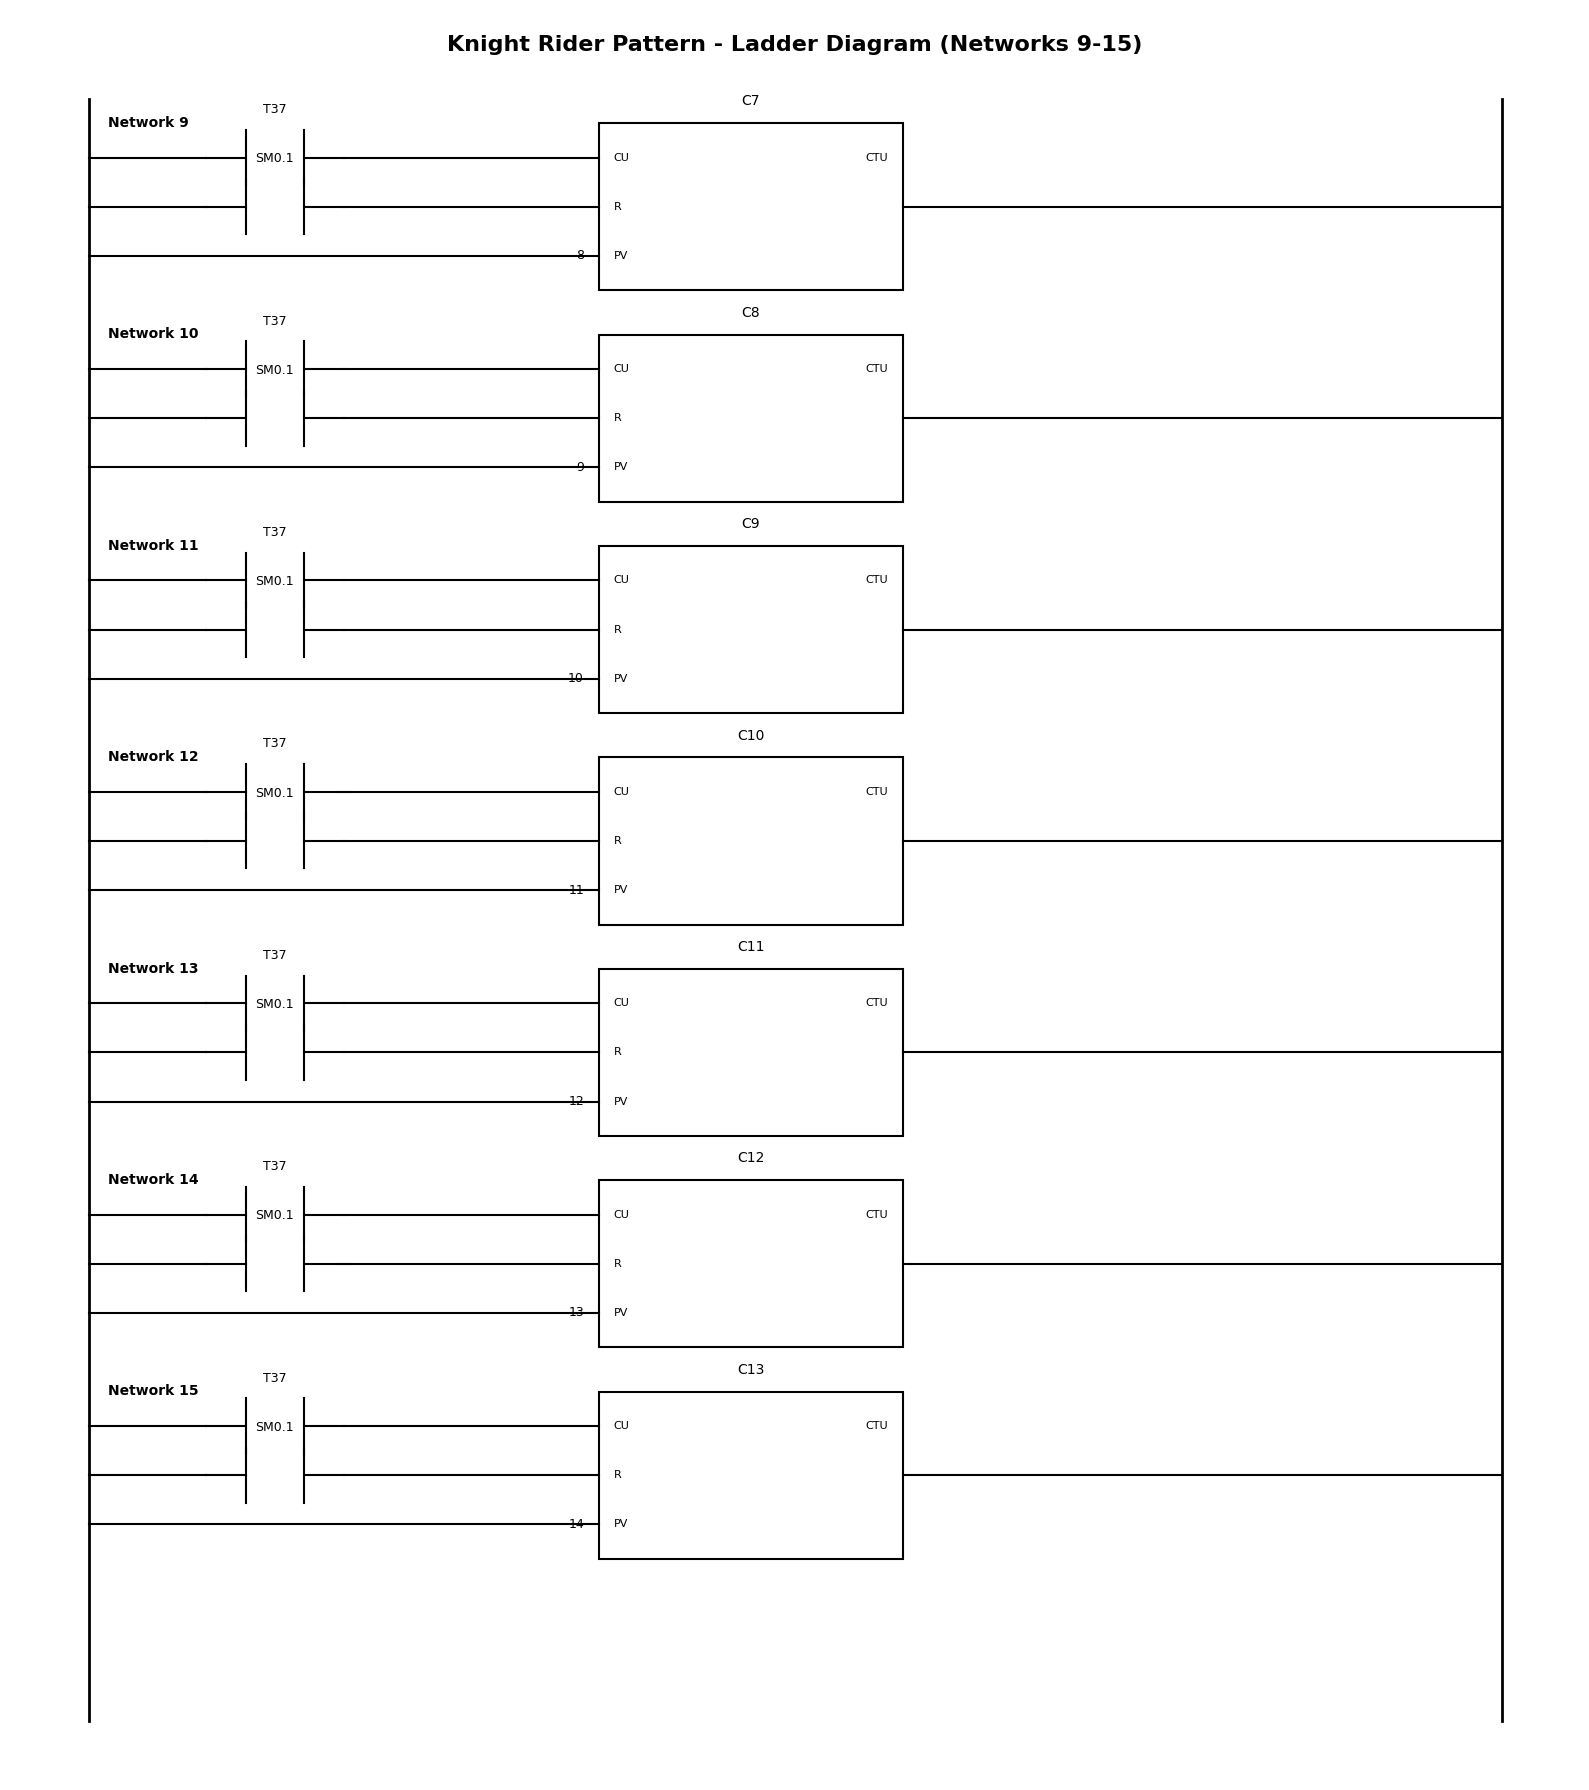

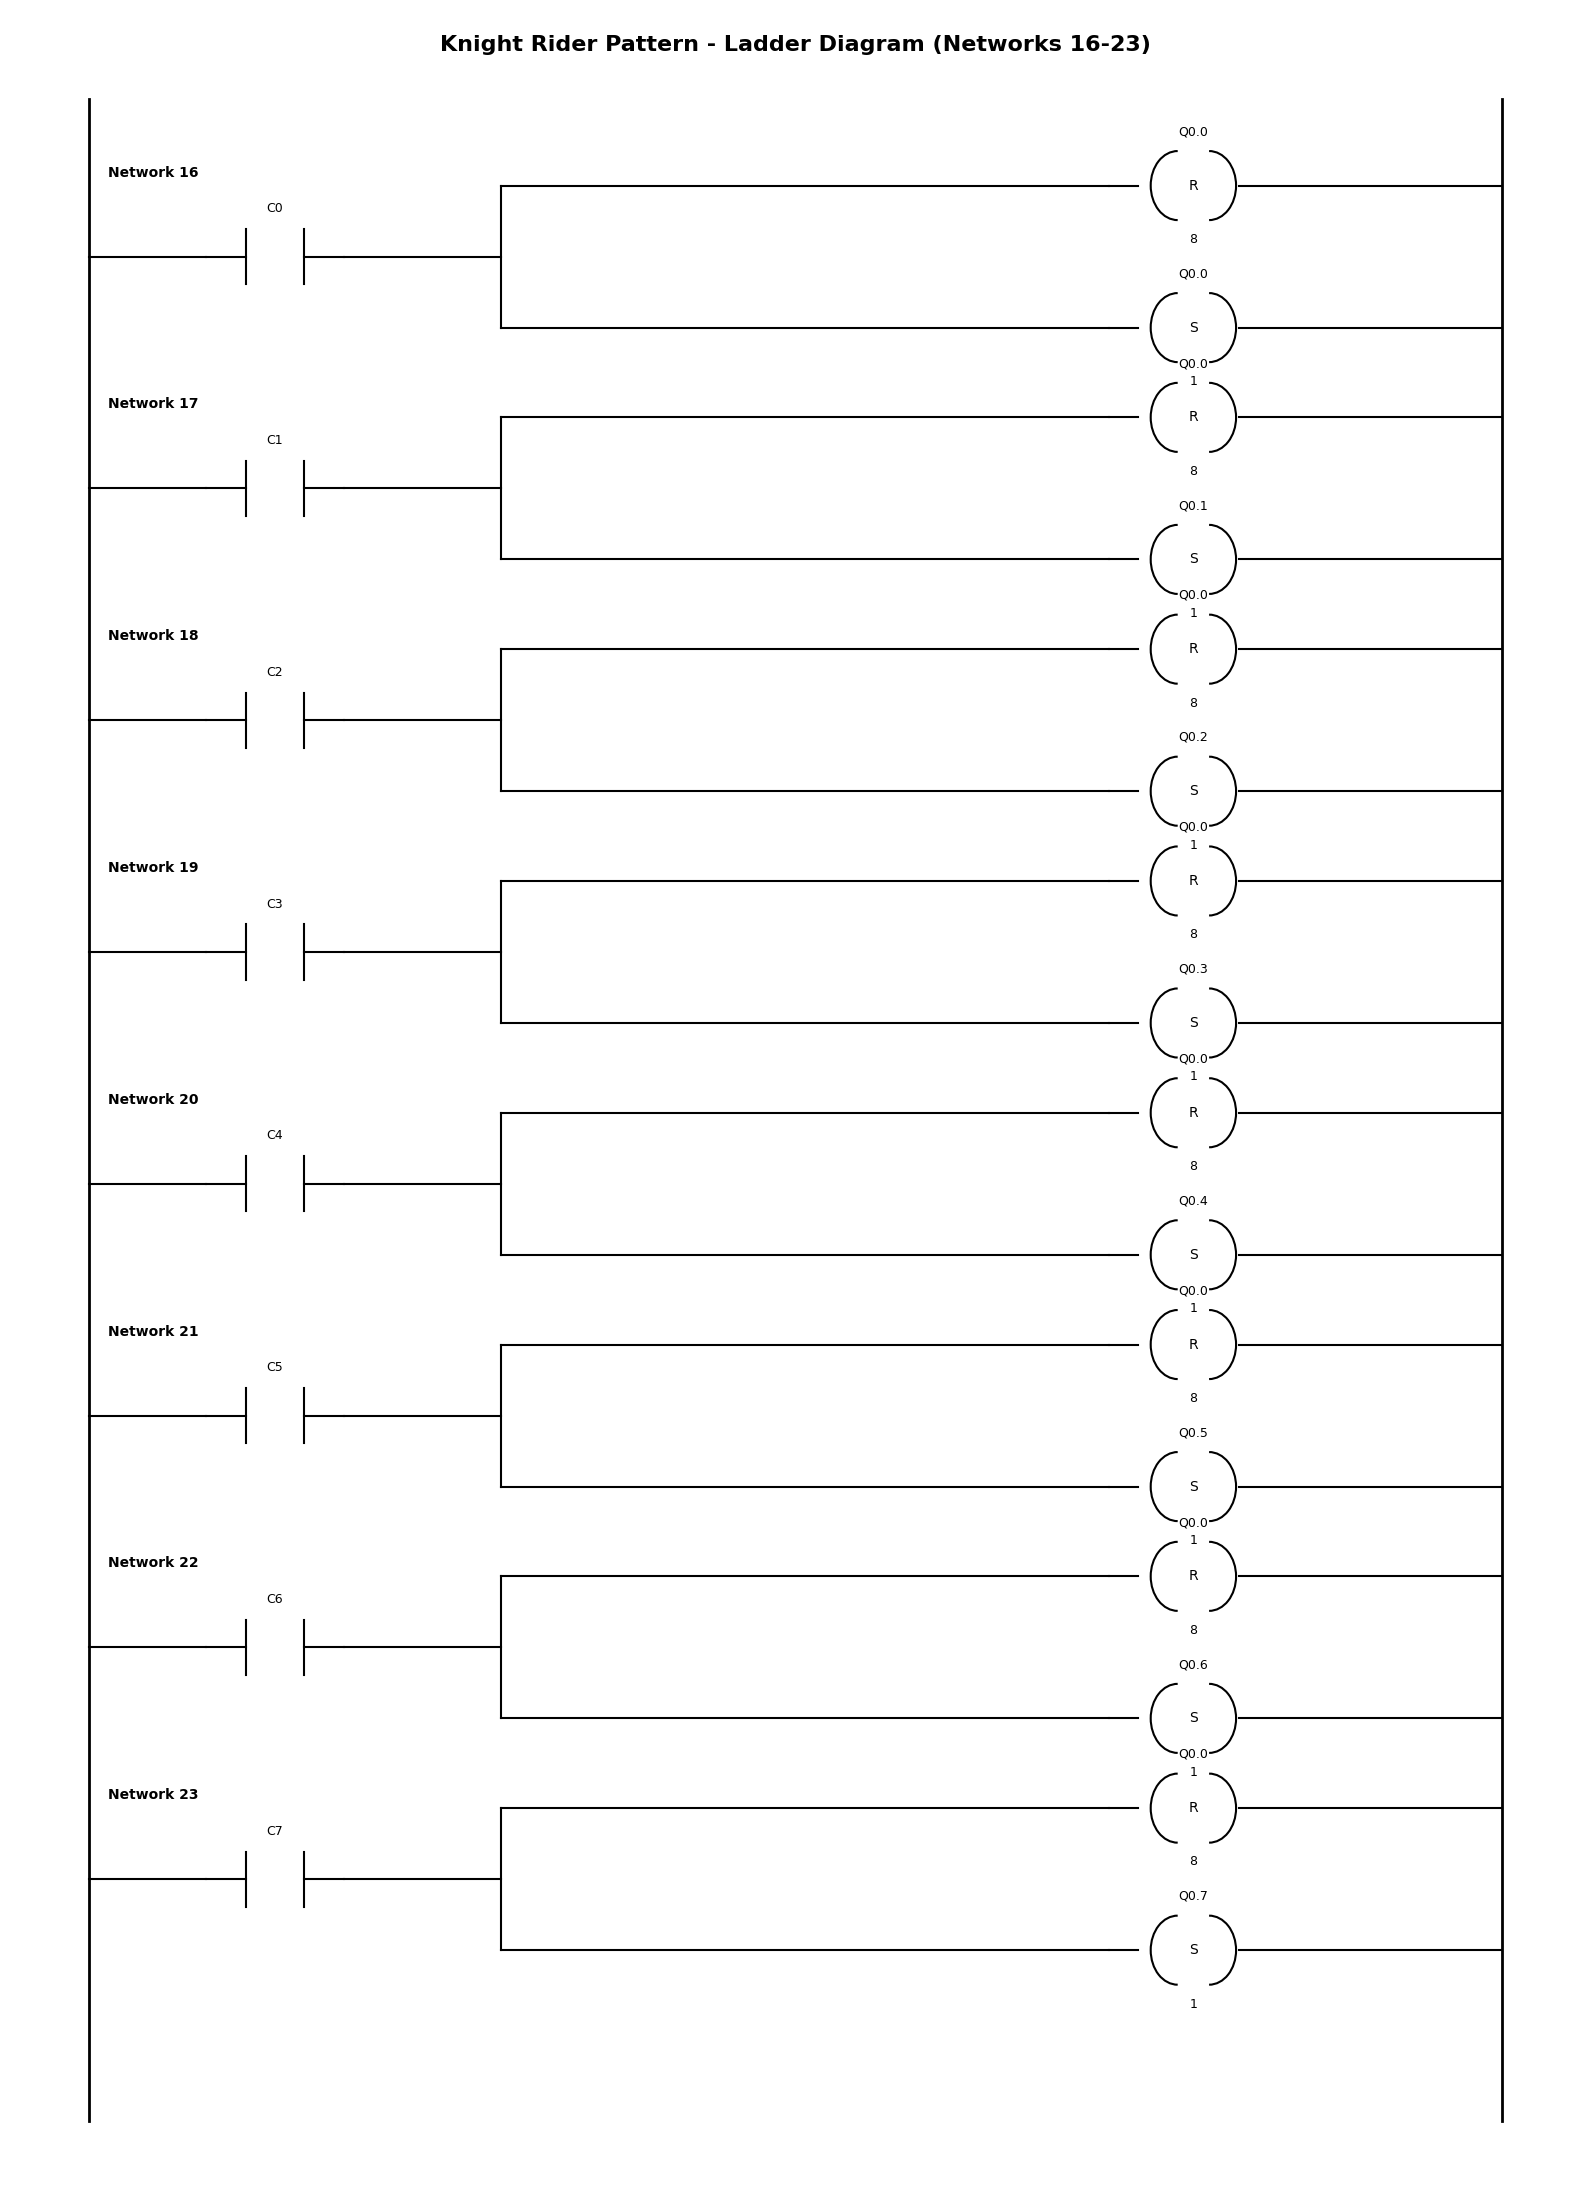

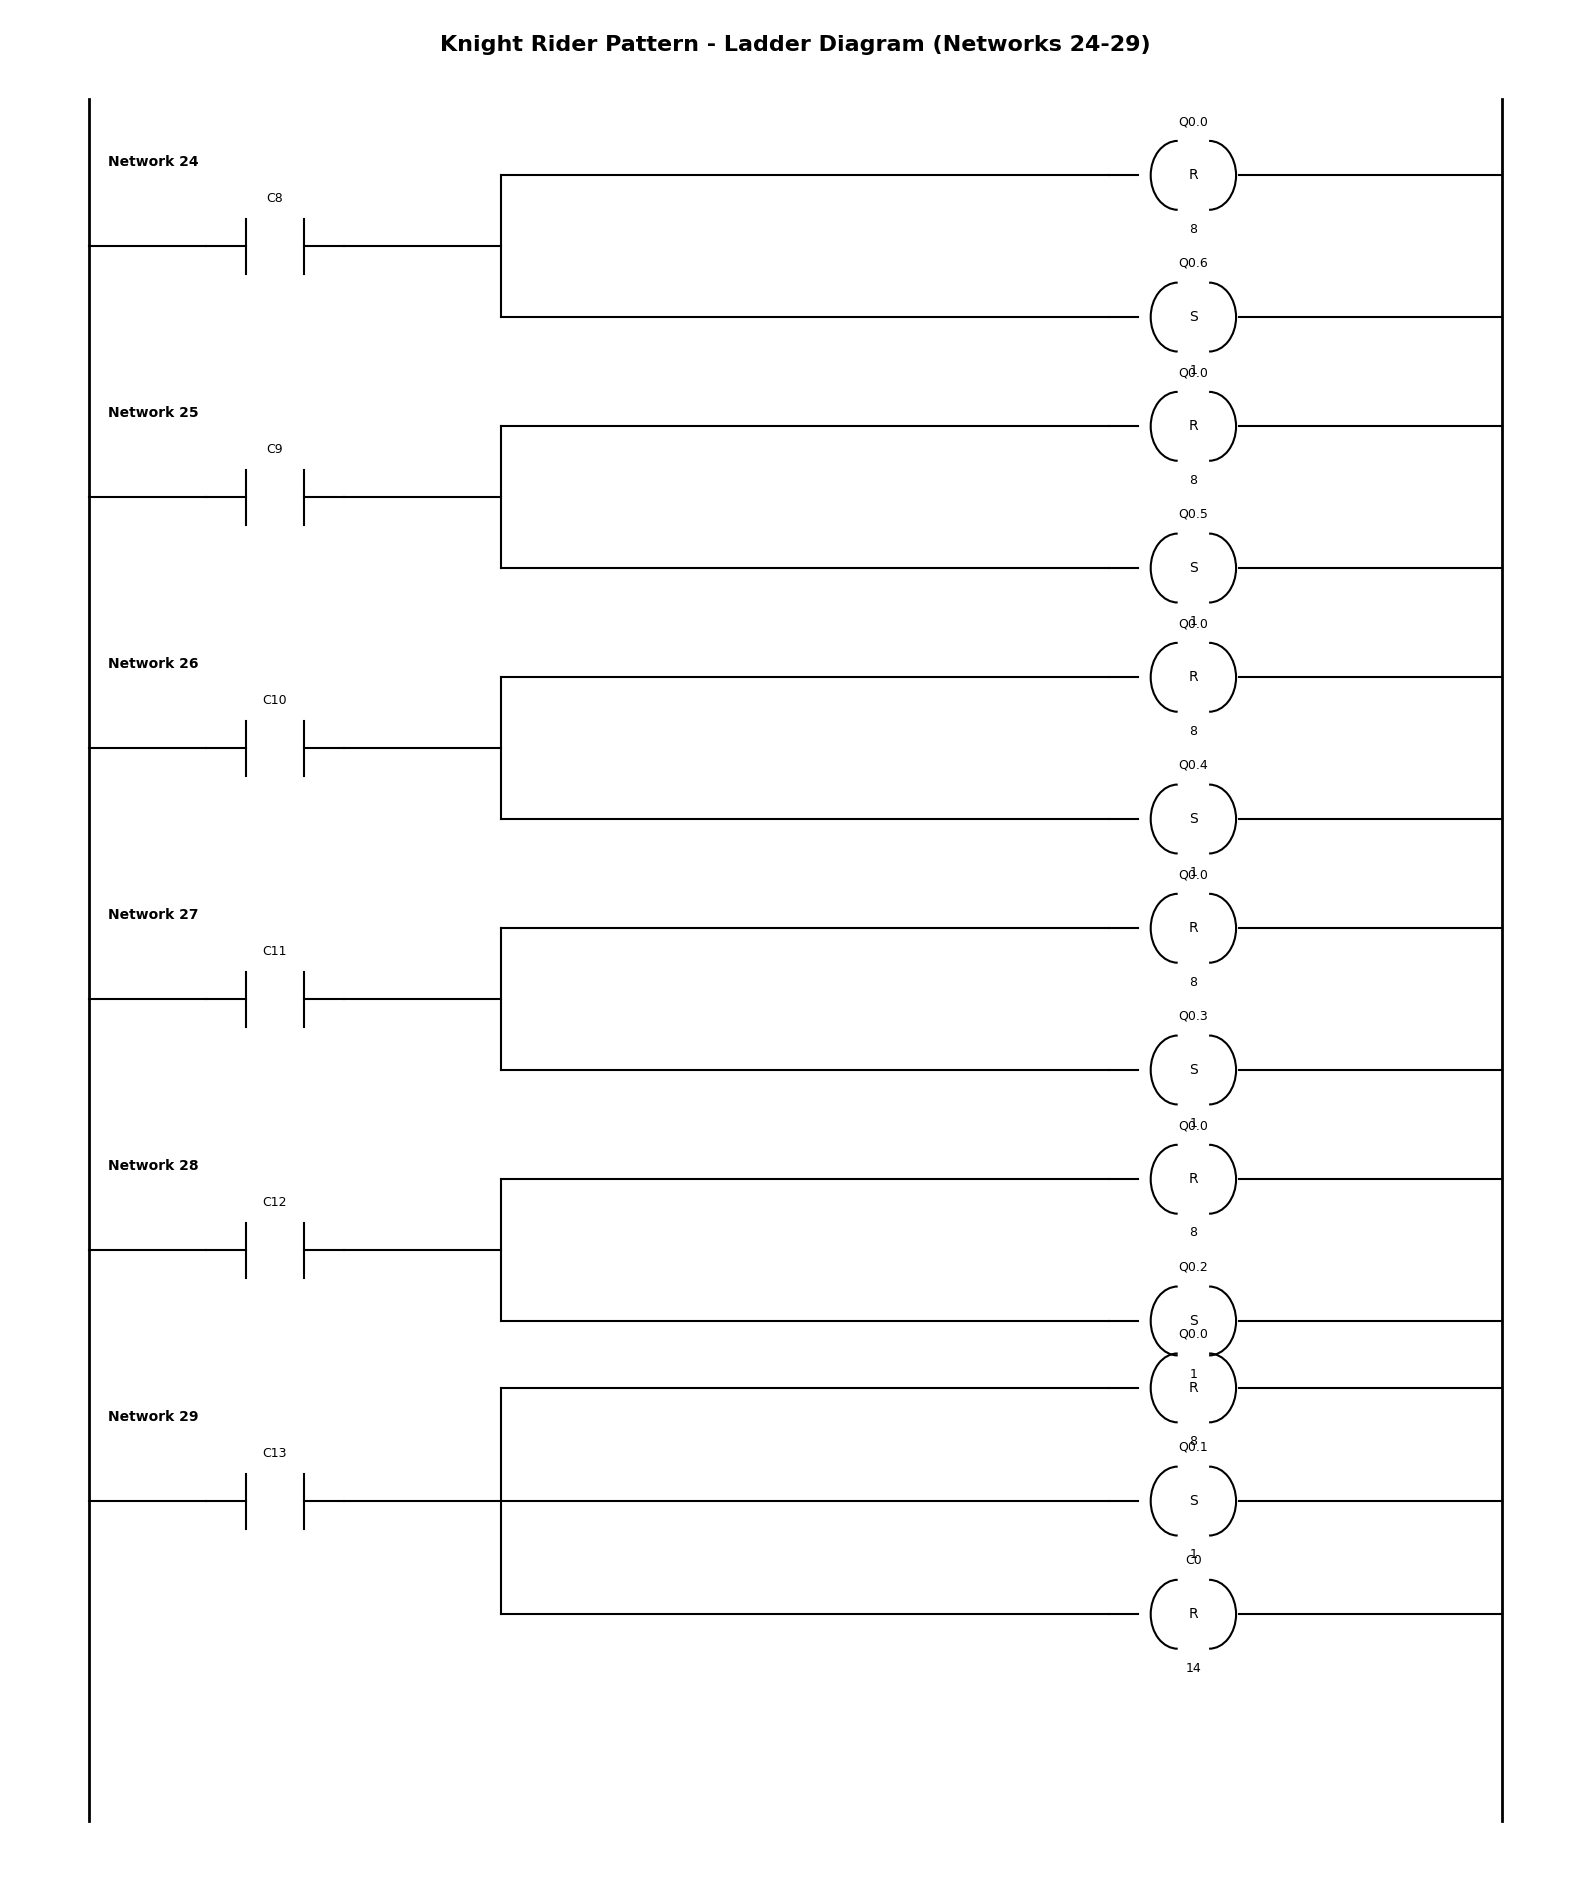

Created files:
knight_rider_outputs/knight_rider_ladder_page_1.png
knight_rider_outputs/knight_rider_ladder_page_2.png
knight_rider_outputs/knight_rider_ladder_page_3.png
knight_rider_outputs/knight_rider_ladder_page_4.png
knight_rider_outputs/knight_rider_ladder_diagram.pdf
knight_rider_ladder_files.zip


In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path
import zipfile

# ============================================================
# KNIGHT RIDER PLC LADDER DIAGRAM
#
# Sequence:
# Q0.0 -> Q0.1 -> Q0.2 -> Q0.3 -> Q0.4 -> Q0.5 -> Q0.6
# -> Q0.7 -> Q0.6 -> Q0.5 -> Q0.4 -> Q0.3 -> Q0.2 -> Q0.1
# -> repeat
# ============================================================

BLACK = "black"
LEFT_RAIL = 0.8
RIGHT_RAIL = 15.2

OUTPUT_DIR = Path("knight_rider_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# BASIC DRAWING FUNCTIONS
# ============================================================

def setup_page(title, height):
    fig, ax = plt.subplots(figsize=(16, height))

    ax.set_xlim(0, 16)
    ax.set_ylim(0, height)
    ax.axis("off")

    # Main power rails
    ax.plot(
        [LEFT_RAIL, LEFT_RAIL],
        [0.6, height - 0.9],
        linewidth=2,
        color=BLACK
    )

    ax.plot(
        [RIGHT_RAIL, RIGHT_RAIL],
        [0.6, height - 0.9],
        linewidth=2,
        color=BLACK
    )

    ax.text(
        8.0,
        height - 0.25,
        title,
        ha="center",
        va="top",
        fontsize=16,
        fontweight="bold",
        color=BLACK
    )

    return fig, ax


def horizontal_wire(ax, x1, x2, y, linewidth=1.5):
    ax.plot(
        [x1, x2],
        [y, y],
        linewidth=linewidth,
        color=BLACK
    )


def vertical_wire(ax, x, y1, y2, linewidth=1.5):
    ax.plot(
        [x, x],
        [y1, y2],
        linewidth=linewidth,
        color=BLACK
    )


def network_label(ax, number, y):
    ax.text(
        1.0,
        y + 0.78,
        f"Network {number}",
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=BLACK
    )


def contact(ax, x, y, label, normally_closed=False):
    """
    Draw a normally open or normally closed contact.
    """

    horizontal_wire(ax, x, x + 0.40, y)

    ax.plot(
        [x + 0.40, x + 0.40],
        [y - 0.28, y + 0.28],
        linewidth=1.5,
        color=BLACK
    )

    ax.plot(
        [x + 1.00, x + 1.00],
        [y - 0.28, y + 0.28],
        linewidth=1.5,
        color=BLACK
    )

    if normally_closed:
        ax.plot(
            [x + 0.35, x + 1.05],
            [y - 0.34, y + 0.34],
            linewidth=1.5,
            color=BLACK
        )

    horizontal_wire(ax, x + 1.00, x + 1.40, y)

    ax.text(
        x + 0.70,
        y + 0.42,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        color=BLACK
    )

    return x + 1.40


def instruction_coil(ax, x, y, address, mode, quantity):
    """
    Draw Siemens-style SET or RESET instruction.

    mode:
        S = Set
        R = Reset
    """

    horizontal_wire(ax, x, x + 0.30, y)

    ax.add_patch(
        Arc(
            (x + 0.70, y),
            0.55,
            0.70,
            theta1=90,
            theta2=270,
            linewidth=1.5,
            color=BLACK
        )
    )

    ax.add_patch(
        Arc(
            (x + 1.02, y),
            0.55,
            0.70,
            theta1=-90,
            theta2=90,
            linewidth=1.5,
            color=BLACK
        )
    )

    ax.text(
        x + 0.86,
        y,
        mode,
        ha="center",
        va="center",
        fontsize=10,
        color=BLACK
    )

    ax.text(
        x + 0.86,
        y + 0.48,
        address,
        ha="center",
        va="bottom",
        fontsize=9,
        color=BLACK
    )

    ax.text(
        x + 0.86,
        y - 0.48,
        str(quantity),
        ha="center",
        va="top",
        fontsize=9,
        color=BLACK
    )

    horizontal_wire(ax, x + 1.32, RIGHT_RAIL, y)


def ton_block(ax, x, y, timer_name, preset, time_base="100 ms"):
    """
    Draw a TON timer block.
    """

    width = 3.0
    height = 1.15

    timer_box = Rectangle(
        (x, y - height / 2),
        width,
        height,
        fill=False,
        linewidth=1.5,
        edgecolor=BLACK
    )

    ax.add_patch(timer_box)

    ax.text(
        x + 0.15,
        y + 0.24,
        "IN",
        ha="left",
        va="center",
        fontsize=8,
        color=BLACK
    )

    ax.text(
        x + width - 0.15,
        y + 0.24,
        "TON",
        ha="right",
        va="center",
        fontsize=8,
        color=BLACK
    )

    ax.text(
        x + 0.15,
        y - 0.28,
        "PT",
        ha="left",
        va="center",
        fontsize=8,
        color=BLACK
    )

    ax.text(
        x + width - 0.15,
        y - 0.28,
        time_base,
        ha="right",
        va="center",
        fontsize=8,
        color=BLACK
    )

    ax.text(
        x + width / 2,
        y + 0.78,
        timer_name,
        ha="center",
        va="bottom",
        fontsize=10,
        color=BLACK
    )

    ax.text(
        x - 0.15,
        y - 0.28,
        str(preset),
        ha="right",
        va="center",
        fontsize=9,
        color=BLACK
    )

    return x + width


def ctu_block(ax, x, y, counter_name, preset):
    """
    Draw a CTU counter block.
    """

    width = 3.1
    height = 1.70

    counter_box = Rectangle(
        (x, y - height / 2),
        width,
        height,
        fill=False,
        linewidth=1.5,
        edgecolor=BLACK
    )

    ax.add_patch(counter_box)

    ax.text(
        x + 0.15,
        y + 0.50,
        "CU",
        ha="left",
        va="center",
        fontsize=8,
        color=BLACK
    )

    ax.text(
        x + 0.15,
        y,
        "R",
        ha="left",
        va="center",
        fontsize=8,
        color=BLACK
    )

    ax.text(
        x + 0.15,
        y - 0.50,
        "PV",
        ha="left",
        va="center",
        fontsize=8,
        color=BLACK
    )

    ax.text(
        x + width - 0.15,
        y + 0.50,
        "CTU",
        ha="right",
        va="center",
        fontsize=8,
        color=BLACK
    )

    ax.text(
        x + width / 2,
        y + 1.00,
        counter_name,
        ha="center",
        va="bottom",
        fontsize=10,
        color=BLACK
    )

    ax.text(
        x - 0.15,
        y - 0.50,
        str(preset),
        ha="right",
        va="center",
        fontsize=9,
        color=BLACK
    )

    return x + width


# ============================================================
# NETWORK FUNCTIONS
# ============================================================

def draw_timer_network(ax, y):
    """
    Network 1:
    Normally closed T37 contact drives TON T37.
    """

    network_label(ax, 1, y)

    horizontal_wire(ax, LEFT_RAIL, 2.0, y)

    x = contact(
        ax,
        2.0,
        y,
        "T37",
        normally_closed=True
    )

    horizontal_wire(ax, x, 5.0, y)

    x = ton_block(
        ax,
        5.0,
        y,
        "T37",
        preset=0
    )

    horizontal_wire(ax, x, RIGHT_RAIL, y)


def draw_counter_network(
    ax,
    network_number,
    y,
    counter_number,
    preset
):
    """
    Networks 2 to 15:

    T37   -> CU
    SM0.1 -> Reset
    PV    -> preset value
    """

    network_label(ax, network_number, y)

    cu_y = y + 0.50
    reset_y = y
    pv_y = y - 0.50

    # T37 input to CU
    horizontal_wire(ax, LEFT_RAIL, 2.0, cu_y)

    x = contact(
        ax,
        2.0,
        cu_y,
        "T37"
    )

    horizontal_wire(ax, x, 6.0, cu_y)

    # SM0.1 input to counter reset
    horizontal_wire(ax, LEFT_RAIL, 2.0, reset_y)

    x = contact(
        ax,
        2.0,
        reset_y,
        "SM0.1"
    )

    horizontal_wire(ax, x, 6.0, reset_y)

    # Preset input line
    horizontal_wire(ax, LEFT_RAIL, 6.0, pv_y)

    end = ctu_block(
        ax,
        6.0,
        y,
        f"C{counter_number}",
        preset
    )

    horizontal_wire(ax, end, RIGHT_RAIL, y)


def draw_output_network(
    ax,
    network_number,
    y,
    counter_name,
    output_name,
    final_network=False
):
    """
    Networks 16 to 29.

    Each counter:
    - Resets eight outputs starting from Q0.0
    - Sets the selected output

    Final network also resets counters C0 to C13.
    """

    network_label(ax, network_number, y)

    horizontal_wire(ax, LEFT_RAIL, 2.0, y)

    x = contact(
        ax,
        2.0,
        y,
        counter_name
    )

    branch_x = 5.0

    horizontal_wire(ax, x, branch_x, y)

    if final_network:
        top_y = y + 1.15
        middle_y = y
        bottom_y = y - 1.15

        vertical_wire(
            ax,
            branch_x,
            bottom_y,
            top_y
        )

        # Reset Q0.0 through Q0.7
        horizontal_wire(ax, branch_x, 11.2, top_y)

        instruction_coil(
            ax,
            11.2,
            top_y,
            "Q0.0",
            "R",
            8
        )

        # Set Q0.1
        horizontal_wire(ax, branch_x, 11.2, middle_y)

        instruction_coil(
            ax,
            11.2,
            middle_y,
            output_name,
            "S",
            1
        )

        # Reset counters C0 through C13
        horizontal_wire(ax, branch_x, 11.2, bottom_y)

        instruction_coil(
            ax,
            11.2,
            bottom_y,
            "C0",
            "R",
            14
        )

    else:
        top_y = y + 0.72
        bottom_y = y - 0.72

        vertical_wire(
            ax,
            branch_x,
            bottom_y,
            top_y
        )

        # Reset all eight outputs
        horizontal_wire(ax, branch_x, 11.2, top_y)

        instruction_coil(
            ax,
            11.2,
            top_y,
            "Q0.0",
            "R",
            8
        )

        # Set selected output
        horizontal_wire(ax, branch_x, 11.2, bottom_y)

        instruction_coil(
            ax,
            11.2,
            bottom_y,
            output_name,
            "S",
            1
        )


# ============================================================
# PAGE 1: NETWORKS 1 TO 8
# ============================================================

fig1, ax1 = setup_page(
    "Knight Rider Pattern - Ladder Diagram (Networks 1-8)",
    height=20
)

y = 18.0

draw_timer_network(ax1, y)

y -= 2.25

for network_number, counter_number, preset in zip(
    range(2, 9),
    range(0, 7),
    range(1, 8)
):
    draw_counter_network(
        ax1,
        network_number,
        y,
        counter_number,
        preset
    )

    y -= 2.15

fig1.tight_layout()

page1_path = OUTPUT_DIR / "knight_rider_ladder_page_1.png"

fig1.savefig(
    page1_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# PAGE 2: NETWORKS 9 TO 15
# ============================================================

fig2, ax2 = setup_page(
    "Knight Rider Pattern - Ladder Diagram (Networks 9-15)",
    height=18
)

y = 16.0

for network_number, counter_number, preset in zip(
    range(9, 16),
    range(7, 14),
    range(8, 15)
):
    draw_counter_network(
        ax2,
        network_number,
        y,
        counter_number,
        preset
    )

    y -= 2.15

fig2.tight_layout()

page2_path = OUTPUT_DIR / "knight_rider_ladder_page_2.png"

fig2.savefig(
    page2_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# PAGE 3: NETWORKS 16 TO 23
# FORWARD SEQUENCE Q0.0 TO Q0.7
# ============================================================

fig3, ax3 = setup_page(
    "Knight Rider Pattern - Ladder Diagram (Networks 16-23)",
    height=22
)

forward_outputs = [
    "Q0.0",
    "Q0.1",
    "Q0.2",
    "Q0.3",
    "Q0.4",
    "Q0.5",
    "Q0.6",
    "Q0.7"
]

y = 19.5

for network_number, counter_number, output_name in zip(
    range(16, 24),
    range(0, 8),
    forward_outputs
):
    draw_output_network(
        ax3,
        network_number,
        y,
        f"C{counter_number}",
        output_name
    )

    y -= 2.35

fig3.tight_layout()

page3_path = OUTPUT_DIR / "knight_rider_ladder_page_3.png"

fig3.savefig(
    page3_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# PAGE 4: NETWORKS 24 TO 29
# REVERSE SEQUENCE Q0.6 TO Q0.1
# ============================================================

fig4, ax4 = setup_page(
    "Knight Rider Pattern - Ladder Diagram (Networks 24-29)",
    height=19
)

reverse_data = [
    (24, "C8",  "Q0.6", False),
    (25, "C9",  "Q0.5", False),
    (26, "C10", "Q0.4", False),
    (27, "C11", "Q0.3", False),
    (28, "C12", "Q0.2", False),
    (29, "C13", "Q0.1", True)
]

y = 16.6

for (
    network_number,
    counter_name,
    output_name,
    is_final
) in reverse_data:

    draw_output_network(
        ax4,
        network_number,
        y,
        counter_name,
        output_name,
        final_network=is_final
    )

    if is_final:
        y -= 3.15
    else:
        y -= 2.55

fig4.tight_layout()

page4_path = OUTPUT_DIR / "knight_rider_ladder_page_4.png"

fig4.savefig(
    page4_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# CREATE MULTIPAGE PDF
# ============================================================

pdf_path = OUTPUT_DIR / "knight_rider_ladder_diagram.pdf"

with PdfPages(pdf_path) as pdf:
    pdf.savefig(
        fig1,
        bbox_inches="tight",
        facecolor="white"
    )

    pdf.savefig(
        fig2,
        bbox_inches="tight",
        facecolor="white"
    )

    pdf.savefig(
        fig3,
        bbox_inches="tight",
        facecolor="white"
    )

    pdf.savefig(
        fig4,
        bbox_inches="tight",
        facecolor="white"
    )


# ============================================================
# CREATE ZIP FILE
# ============================================================

zip_path = Path("knight_rider_ladder_files.zip")

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    files_to_zip = [
        page1_path,
        page2_path,
        page3_path,
        page4_path,
        pdf_path
    ]

    for file_path in files_to_zip:
        zip_file.write(
            file_path,
            arcname=file_path.name
        )


plt.show()

print("Created files:")

print(page1_path)
print(page2_path)
print(page3_path)
print(page4_path)
print(pdf_path)
print(zip_path)

In [6]:
from google.colab import files

files.download("knight_rider_ladder_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from google.colab import files

files.download("knight_rider_outputs/knight_rider_ladder_page_1.png")
files.download("knight_rider_outputs/knight_rider_ladder_page_2.png")
files.download("knight_rider_outputs/knight_rider_ladder_page_3.png")
files.download("knight_rider_outputs/knight_rider_ladder_page_4.png")
files.download("knight_rider_outputs/knight_rider_ladder_diagram.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>